## Ran Uram  
## Shahar Lankry  
## Daniel Geron 
-------------------------

## Importing Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')
import cv2
import os
from tqdm import tqdm
import collections
import numpy as np
import urllib.request
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Activation, Dense, Flatten
from sklearn import metrics
import seaborn as sns

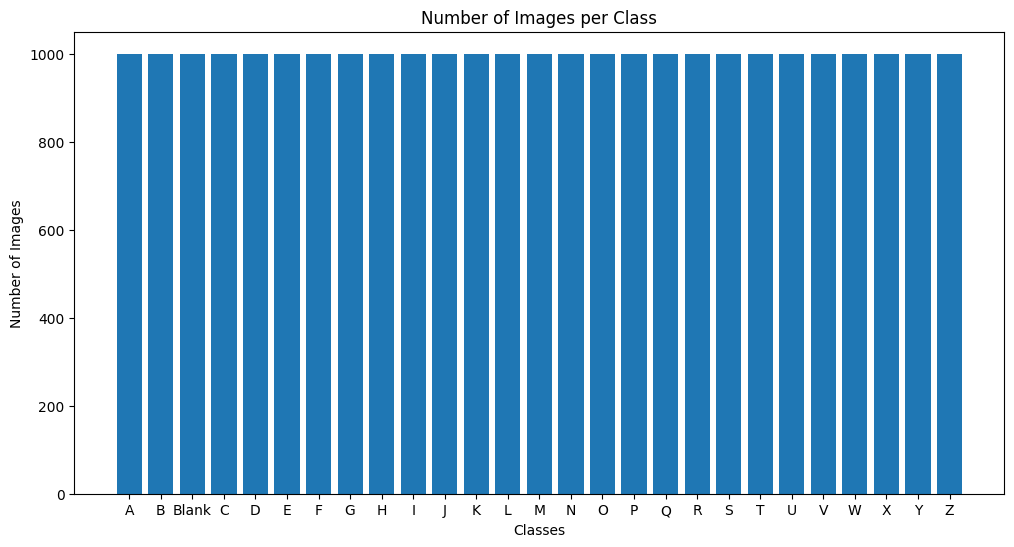

In [ ]:
d={}
data_dir = #path to the dataset saved locally
for subdir in os.listdir(data_dir):
    subdir_path = os.path.join(data_dir, subdir)
    if os.path.isdir(subdir_path):
        num_images = len([f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        d[subdir] = num_images
figs, ax = plt.subplots(figsize=(12, 6))
ax.bar(d.keys(), d.values())
ax.set_xlabel('Classes')
ax.set_ylabel('Number of Images')
ax.set_title('Number of Images per Class')
plt.show()

## Importing data

In [5]:
X=[]
Y=[]
for subdir in os.listdir(data_dir):
    if subdir=="Blank":
        continue
    subdir_path = os.path.join(data_dir, subdir)
    if os.path.isdir(subdir_path):
        filenames= os.listdir(subdir_path)
        for filename in filenames: 
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(subdir_path, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    X.append(img)
                    Y.append(subdir)
        print(f"finished putting labels for {subdir}")

print(f"Total images loaded: {len(X)}")
print(f"Total labels loaded: {len(Y)}")


finished putting labels for A
finished putting labels for B
finished putting labels for C
finished putting labels for D
finished putting labels for E
finished putting labels for F
finished putting labels for G
finished putting labels for H
finished putting labels for I
finished putting labels for J
finished putting labels for K
finished putting labels for L
finished putting labels for M
finished putting labels for N
finished putting labels for O
finished putting labels for P
finished putting labels for Q
finished putting labels for R
finished putting labels for S
finished putting labels for T
finished putting labels for U
finished putting labels for V
finished putting labels for W
finished putting labels for X
finished putting labels for Y
finished putting labels for Z
Total images loaded: 26000
Total labels loaded: 26000


## Resizing the images to the desired size, and also normalize them

In [6]:
new_size = (128, 128)
print("Resizing images in memory...")


for i in range(len(X)):
    img=X[i]
    img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img=img/255.0
    X[i]=img
print(f"Done! X now contains {len(X)} images at resolution {new_size}")

Resizing images in memory...
Done! X now contains 26000 images at resolution (128, 128)


## A plot showcasing 9 random images from our dataset

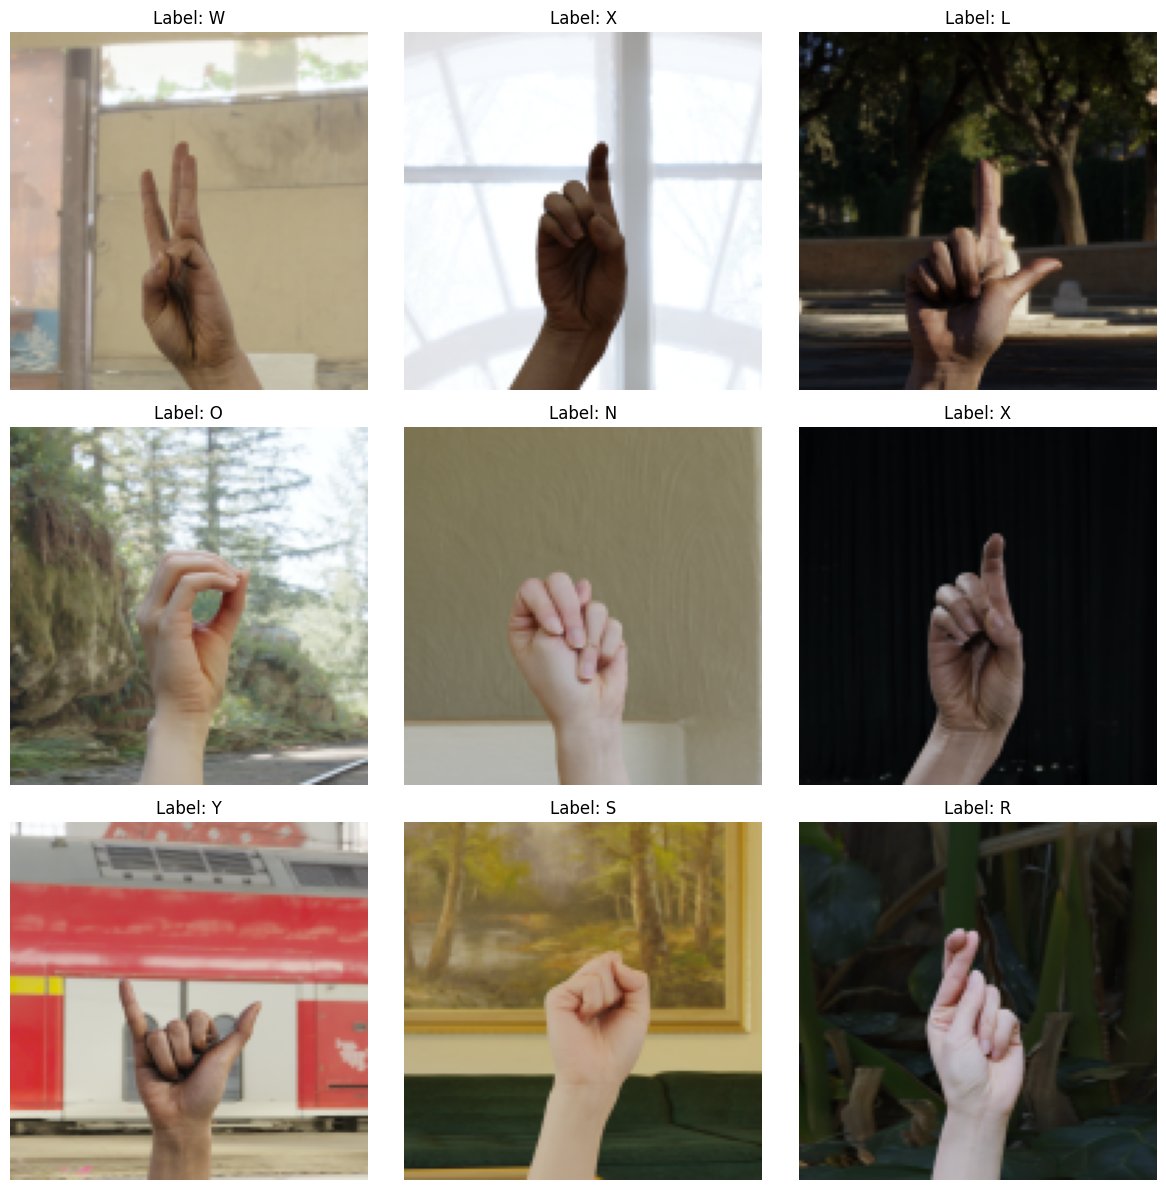

In [7]:
num_samples = 9
random_indices = random.sample(range(len(X)), num_samples)
plt.figure(figsize=(12, 12))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    img = X[idx]
    label = Y[idx] 
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Making copies of data

In [8]:
X_data=np.array(X)
Y_data=np.array(Y)

## One hot encoding of the dataset Labels

In [9]:
le=LabelEncoder()
Y_integers=le.fit_transform(Y_data)
num_classes=len(le.classes_)

y_onehot=to_categorical(Y_integers,num_classes=num_classes)

print("One-Hot shape:", y_onehot.shape)
print("Example conversion:")
print(f"Original: {Y_data[0]}")
print(f"Integer:  {Y_integers[0]}")
print(f"One-Hot:  {y_onehot[0]}")

One-Hot shape: (26000, 26)
Example conversion:
Original: A
Integer:  0
One-Hot:  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


## Splitting our X and Y lists into train,validation and test

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X_data, y_onehot, test_size=0.2, random_state=42)

In [11]:
print(f"Train: {x_train.shape}, {y_train.shape}")
print(f"Test: {x_test.shape}, {y_test.shape}")

Train: (20800, 128, 128, 3), (20800, 26)
Test: (5200, 128, 128, 3), (5200, 26)


In [12]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [13]:
print(f"After split - Train: {x_train.shape}, {y_train.shape}")
print(f"Validation: {x_val.shape}, {y_val.shape}")

After split - Train: (16640, 128, 128, 3), (16640, 26)
Validation: (4160, 128, 128, 3), (4160, 26)


## Building Model1 (Baseline: 128X128 resulution)

In [14]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3))) 
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

# Block 2
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

# Block 3
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(Activation('relu')) 
model.add(MaxPooling2D((2, 2)))

# ... Flatten and Dense layers ...
model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))               
model.add(Dense(26, activation='softmax'))  

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,884,314 (64.41 MB)

 Trainable params: 16,884,314 (64.41 MB)

 Non-trainable params: 0 (0.00 B)

## Defining early stop 

In [15]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [16]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Compiling and training the model

In [17]:
print("\nStarting training... monitoring Validation Accuracy only.")
history = model.fit(
    x_train, y_train,
    epochs=30, 
    validation_data=(x_val, y_val), 
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


Starting training... monitoring Validation Accuracy only.
Epoch 1/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 177s 333ms/step - accuracy: 0.6730 - loss: 1.1561 - val_accuracy: 0.9252 - val_loss: 0.2358
Epoch 2/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 168s 323ms/step - accuracy: 0.9685 - loss: 0.1038 - val_accuracy: 0.9721 - val_loss: 0.0928
Epoch 3/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 166s 319ms/step - accuracy: 0.9889 - loss: 0.0334 - val_accuracy: 0.9654 - val_loss: 0.1219
Epoch 4/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 166s 320ms/step - accuracy: 0.9933 - loss: 0.0240 - val_accuracy: 0.9755 - val_loss: 0.0919
Epoch 5/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 165s 318ms/step - accuracy: 0.9932 - loss: 0.0234 - val_accuracy: 0.9764 - val_loss: 0.0977
Epoch 6/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 164s 316ms/step - accuracy: 0.9973 - loss: 0.0113 - val_accuracy: 0.9815 - val_loss: 0.0717
Epoch 7/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 168s 324ms/step - accuracy: 0.9928 - loss: 0.0259 - val_accuracy: 0.9608 - val_loss: 0.1435
Epoch 8/30
520/52

## Graph showing accuracy and loss of validation data compared to training data

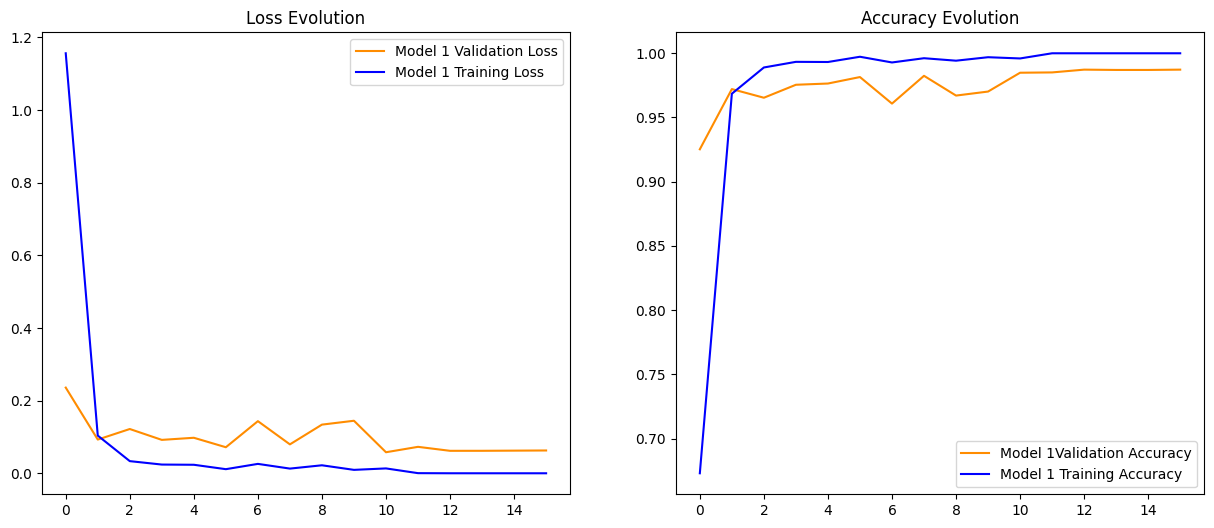

In [18]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['val_loss'], label='Model 1 Validation Loss', color='darkorange')
plt.plot(model.history.history['loss'], label='Model 1 Training Loss', color='blue')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['val_accuracy'], label='Model 1Validation Accuracy', color='darkorange')
plt.plot(model.history.history['accuracy'], label='Model 1 Training Accuracy', color='blue')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

## Evaluating on test and showing its results

In [19]:
res=model.evaluate(x_test, y_test)
print(res)

163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.9856 - loss: 0.0700
[0.07000239193439484, 0.9855769276618958]


In [20]:
model.metrics_names

['loss', 'compile_metrics']

## Showcasing 3 picture from the test the model classify correctly and 3 that were not

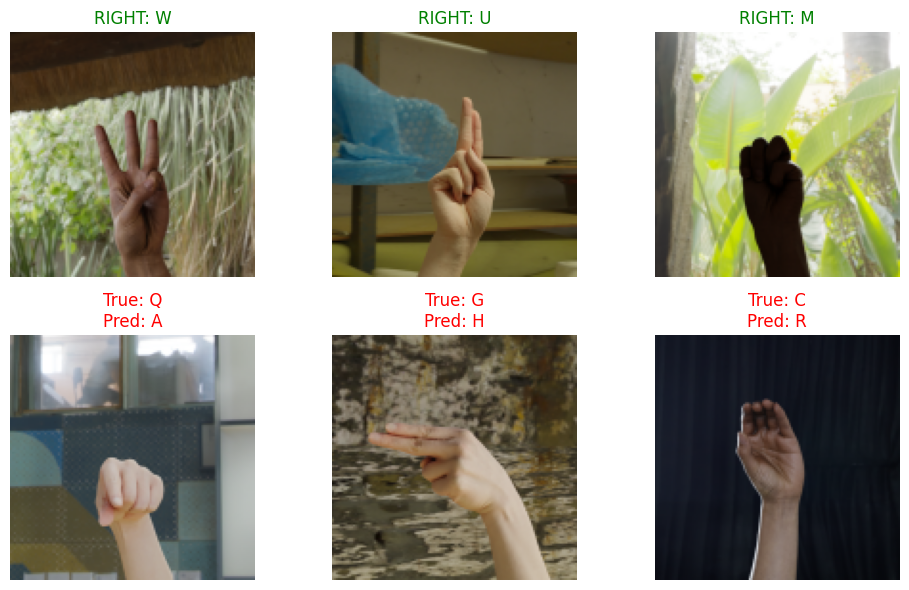

In [21]:
def show_3_right_3_wrong(model, X_test, y_test, class_names):
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    right_indices = np.where(y_true == y_pred)[0]
    wrong_indices = np.where(y_true != y_pred)[0]

    num_samples = 3
    

    if len(right_indices) >= num_samples:
        right_samples = np.random.choice(right_indices, num_samples, replace=False)
    else:
        right_samples = right_indices 

   
    if len(wrong_indices) >= num_samples:
        wrong_samples = np.random.choice(wrong_indices, num_samples, replace=False)
    else:
        wrong_samples = wrong_indices

    plt.figure(figsize=(10, 6))

  
    for i, idx in enumerate(right_samples):
        plt.subplot(2, 3, i + 1)
        plt.imshow(X_test[idx])
        plt.title(f"RIGHT: {class_names[y_true[idx]]}", color='green', fontsize=12)
        plt.axis("off")

    for i, idx in enumerate(wrong_samples):
        plt.subplot(2, 3, 3 + i + 1) # Start from 4th position
        plt.imshow(X_test[idx])
        plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", color='red', fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


class_names = le.classes_
show_3_right_3_wrong(model, x_test, y_test, class_names)

## Classification report of the model and confusion matrix

In [22]:
y_true = np.argmax(y_test, axis=1) 
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
class_names = le.classes_

In [23]:
print("--- Classification Report ---\n")
print(metrics.classification_report(y_true, y_pred, target_names=class_names))

--- Classification Report ---

              precision    recall  f1-score   support

           A       0.98      0.98      0.98       191
           B       1.00      0.99      1.00       182
           C       0.99      1.00      0.99       218
           D       0.99      0.97      0.98       219
           E       0.97      0.99      0.98       195
           F       0.97      0.99      0.98       191
           G       0.99      0.99      0.99       230
           H       0.98      0.97      0.98       192
           I       1.00      1.00      1.00       212
           J       0.97      0.98      0.98       214
           K       0.99      1.00      0.99       209
           L       0.97      0.98      0.98       213
           M       0.98      0.98      0.98       221
           N       0.98      0.97      0.97       187
           O       0.99      0.99      0.99       195
           P       0.99      0.98      0.99       194
           Q       0.98      0.96      0.97       

confusion matrix:


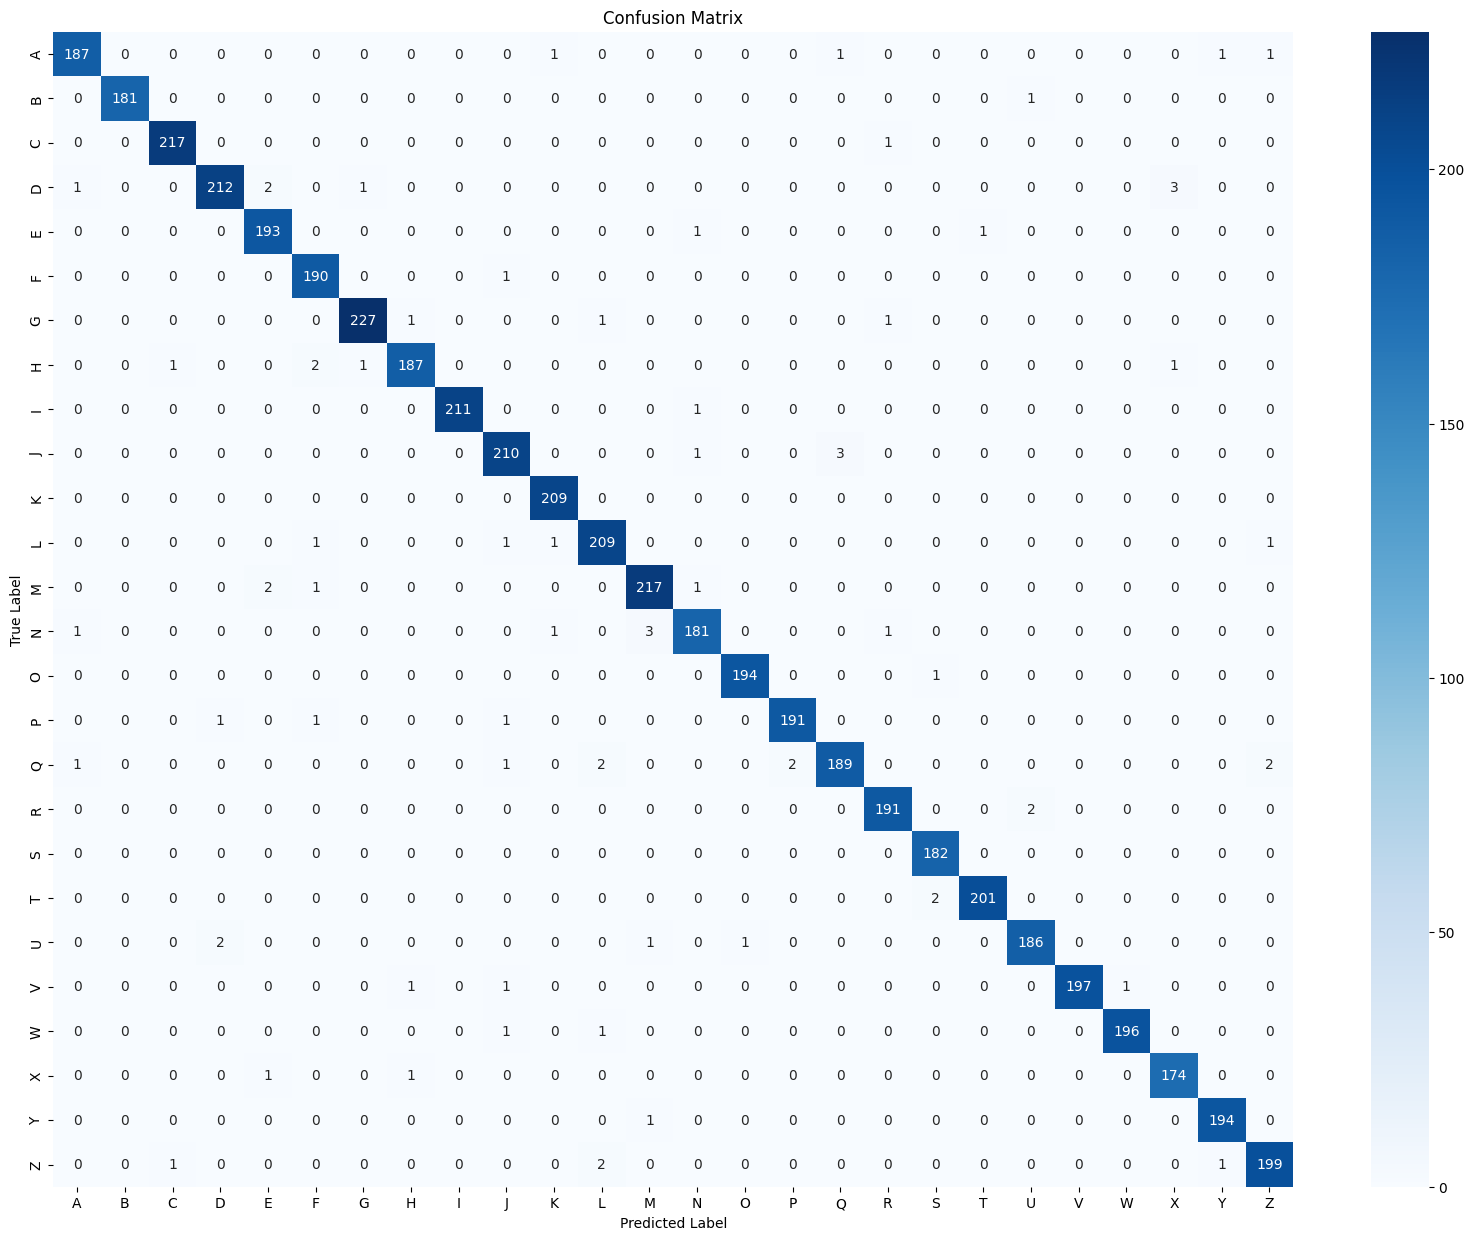

In [24]:
print("confusion matrix:")
matrix=metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20,15))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()